Datenstrukur wird angepasst
berechnete beat_len: 300


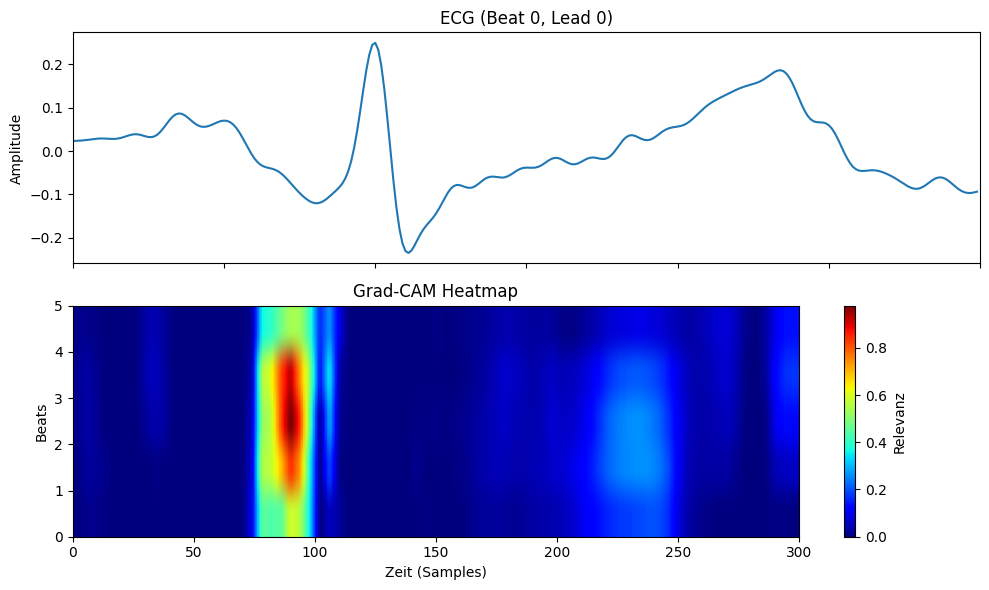

In [3]:
from functions import make_gradcam_heatmap, load_X_split
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

def main():
    l = 100
    x_path = 'ready_data/X/'
    y_path = 'ready_data/y/'  # aufpassen: klein "y", wie beim Speichern!

    print('Datenstrukur wird angepasst')
    print('='*l)

    # === X laden ===
    X_test = load_X_split(x_path, "test")

    # === Model laden ===
    model = tf.keras.models.load_model("models/CNN_84.71_.keras")

    # Beispiel auswählen
    i = 0
    input_image = X_test[i:i + 1]  # Shape (1, H, W, C)

    # Grad-CAM Heatmap berechnen
    heatmap = make_gradcam_heatmap(
        img_array=input_image,
        model=model,
        last_conv_layer_name="conv2d_2",  # ggf. anpassen
        class_index=None,                 # None -> nimmt argmax prediction
    )

    # Input & Heatmap auf gleiche Größe bringen (Beats x Zeit)
    inp = input_image[0]              # z.B. (5, 300, 12)
    H_in, W_in = inp.shape[:2]

    heatmap_resized = tf.image.resize(
        heatmap[np.newaxis, ..., np.newaxis],  # (1, Hc, Wc, 1)
        (H_in, W_in)
    )[0, ..., 0].numpy()  # -> (H_in, W_in), z.B. (5, 300)

    # ---------------- ECG + Heatmap plotten ----------------

    # Einen Beat und Lead auswählen
    beat_idx = 0      # 0..H_in-1
    lead_idx = 0      # 0..(n_leads-1)

    ecg_signal = inp[beat_idx, :, lead_idx]        # Shape (W_in,)
    cam_row    = heatmap_resized[beat_idx, :]      # Shape (W_in,)

    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))

    # (1) ECG-Signal
    ax1.plot(np.arange(W_in), ecg_signal)
    ax1.set_ylabel("Amplitude")
    ax1.set_title(f"ECG (Beat {beat_idx}, Lead {lead_idx})")

    # (2) Grad-CAM-Heatmap (alle Beats)
    im = ax2.imshow(
        heatmap_resized,
        cmap="jet",
        aspect="auto",
        origin="lower",
        extent=[0, W_in, 0, H_in],  # x: Zeit, y: Beats
    )
    fig.colorbar(im, ax=ax2, label="Relevanz")
    ax2.set_xlabel("Zeit (Samples)")
    ax2.set_ylabel("Beats")
    ax2.set_title("Grad-CAM Heatmap")

    plt.tight_layout()
    plt.show()

main()


Datenstrukur wird angepasst
berechnete beat_len: 300


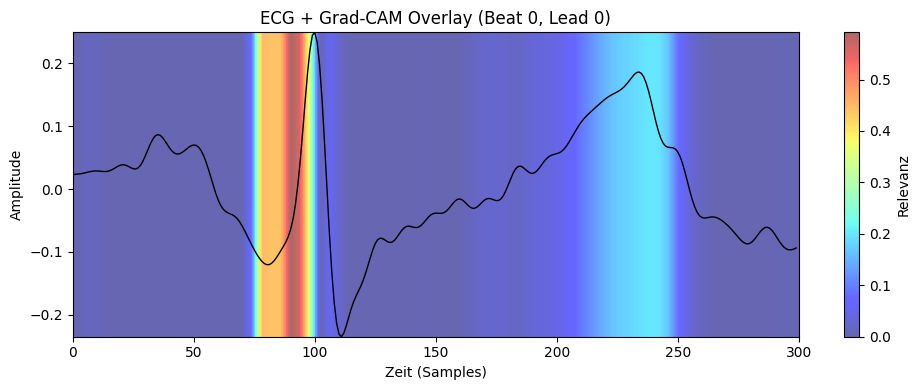

In [4]:
from functions import make_gradcam_heatmap, load_X_split
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

def main():
    l = 100
    x_path = 'ready_data/X/'
    y_path = 'ready_data/y/'  # aufpassen: klein "y", wie beim Speichern!

    print('Datenstrukur wird angepasst')
    print('='*l)

    # === X laden ===
    X_test = load_X_split(x_path, "test")

    # === Model laden ===
    model = tf.keras.models.load_model("models/CNN_84.71_.keras")

    # Beispiel auswählen
    i = 0
    input_image = X_test[i:i + 1]  # Shape (1, H, W, C)

    # Grad-CAM Heatmap berechnen
    heatmap = make_gradcam_heatmap(
        img_array=input_image,
        model=model,
        last_conv_layer_name="conv2d_2",  # ggf. anpassen
        class_index=None,                 # None -> nimmt argmax prediction
    )

    # Input & Heatmap auf gleiche Größe bringen (Beats x Zeit)
    inp = input_image[0]              # z.B. (5, 300, 12)
    H_in, W_in = inp.shape[:2]

    heatmap_resized = tf.image.resize(
        heatmap[np.newaxis, ..., np.newaxis],  # (1, Hc, Wc, 1)
        (H_in, W_in)
    )[0, ..., 0].numpy()  # -> (H_in, W_in), z.B. (5, 300)

    # ---------------- ECG + Grad-CAM überlagern ----------------

    # Beat und Lead wählen
    beat_idx = 0      # 0..H_in-1
    lead_idx = 0      # 0..(n_leads-1)

    ecg_signal = inp[beat_idx, :, lead_idx]        # Shape (W_in,)
    cam_row    = heatmap_resized[beat_idx, :]      # Shape (W_in,)

    # etwas skalieren/normalisieren
    ecg_min, ecg_max = ecg_signal.min(), ecg_signal.max()

    fig, ax = plt.subplots(figsize=(10, 4))

    # Heatmap als Hintergrund (1D-Heatmap -> 2D machen)
    im = ax.imshow(
        cam_row[np.newaxis, :],              # Shape (1, W_in)
        cmap="jet",
        aspect="auto",
        origin="lower",
        extent=[0, W_in, ecg_min, ecg_max],  # x=Zeit, y=Amplitude
        alpha=0.6,                           # Transparenz
    )

    # ECG-Signal darüber
    ax.plot(np.arange(W_in), ecg_signal, color="black", linewidth=1.0)

    fig.colorbar(im, ax=ax, label="Relevanz")
    ax.set_xlabel("Zeit (Samples)")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"ECG + Grad-CAM Overlay (Beat {beat_idx}, Lead {lead_idx})")

    plt.tight_layout()
    plt.show()

main()
